In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("../DataSet/house_price.csv")
df.head

<bound method NDFrame.head of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  con

In [6]:
# x_train = np.array(df["sqft_living"])
# y_train = np.round(np.array(df["price"]), 2)

# x_train = np.array(
#     [150000, 200000, 250000, 280000, 320000, 350000, 400000, 420000, 480000, 500000],
#     dtype=float,
# )

# y_train = np.array(
#     [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3200], dtype=float
# )

x_train = df["sqft_living"].to_numpy()
y_train = df["price"].to_numpy().round(2)

print(f"House prices: {x_train[:10]}")
print(f"SQFT: {y_train[:10]}")

House prices: [1340 3650 1930 2000 1940  880 1350 2710 2430 1520]
SQFT: [ 313000. 2384000.  342000.  420000.  550000.  490000.  335000.  482000.
  452500.  640000.]


In [7]:
x_train.shape[0]

4600

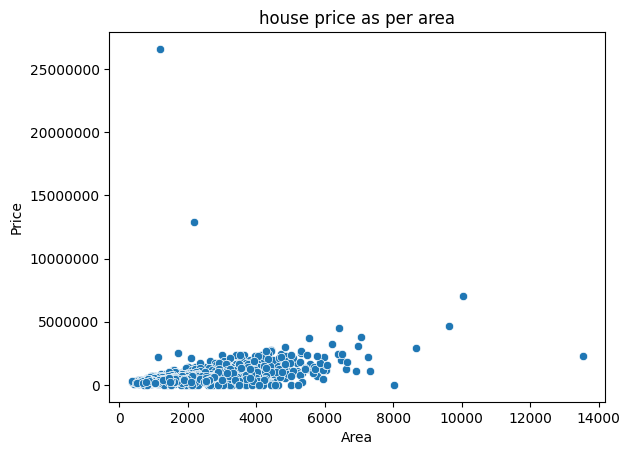

In [ ]:
sns.scatterplot(x=x_train, y=y_train)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("house price as per area")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [9]:
w = 0
b = 0
learning_rate = 1e-10  # alpha
iterations = 10000

In [10]:
def compute_output(x: np.ndarray, w, b) -> np.ndarray:
    # without vectorization
    # m = x.shape[0]
    # f_wb = np.zeros(m)  # model prediction

    # f_wb = w * x + b

    # return f_wb

    # With vectorization
    return w * x + b

In [11]:
def compute_cost(x: np.ndarray, y: np.ndarray, w, b):

    m = x.shape[0]

    # cost = 0

    # for i in range(m):
    #     f_wb = w * x[i] + b
    #     sq_error = (f_wb - y[i]) ** 2
    #     cost += sq_error

    # total_cost = cost / (2 * m)

    y_hat = w * x + b
    sq_error = (y_hat - y) ** 2

    cost = np.sum(sq_error)

    cost = cost / (2 * m)

    return cost

In [ ]:
def gradient_descent(x, y, w_in, b_in, alpha, iterations):
    w = w_in
    b = b_in

    m = x.shape[0]

    cost_history = []

    for i in range(iterations):

        f_wd = compute_output(x, w, b)

        # for j in range(m):

        #     df_dw_j = (f_wd[j] - y[j]) * x[j]
        #     df_db_j = f_wd[j] - y[j]

        #     df_dw += df_dw_j
        #     df_db += df_db_j

        # df_dw /= m
        # df_db /= m

        y_hat = w * x + b
        error = y_hat - y

        df_dw = np.sum(error * x) / m
        df_db = np.sum(error) / m

        w = w - alpha * df_dw
        b = b - alpha * df_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 1000 == 0:
            print(f"Iteration {i}, Cost: {cost}")

        if len(cost_history) > 1:  # convergence checking / early stopping
            if abs(cost_history[-1] - cost_history[-2]) < 1:
                break

    return w, b, cost_history

In [13]:
w_final, b_final, cost_hist = gradient_descent(
    x_train, y_train, w, b, learning_rate, iterations
)

print(f"Final values:\nw = {w_final}\nb = {b_final}")

Iteration 0, Cost: 311051763333.0263
Iteration 1000, Cost: 189858176929.05597
Iteration 2000, Cost: 149563811590.83112
Iteration 3000, Cost: 136166767025.9144
Iteration 4000, Cost: 131712526300.78119
Iteration 5000, Cost: 130231583220.82484
Iteration 6000, Cost: 129739200221.71092
Iteration 7000, Cost: 129575493039.84006
Iteration 8000, Cost: 129521063781.41948
Iteration 9000, Cost: 129502967176.41345
Final values:
w = 255.94085630514834
b = 0.10165777349831369


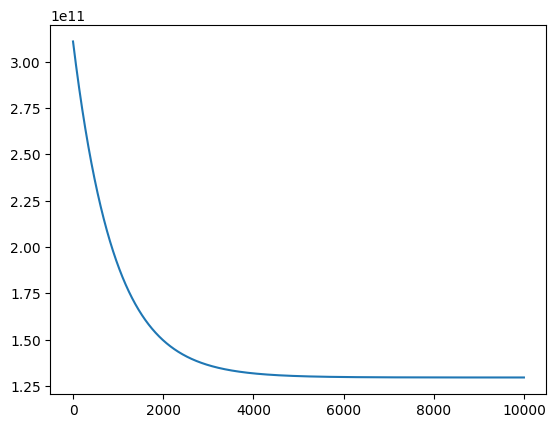

In [14]:
plt.plot(cost_hist)
plt.show()

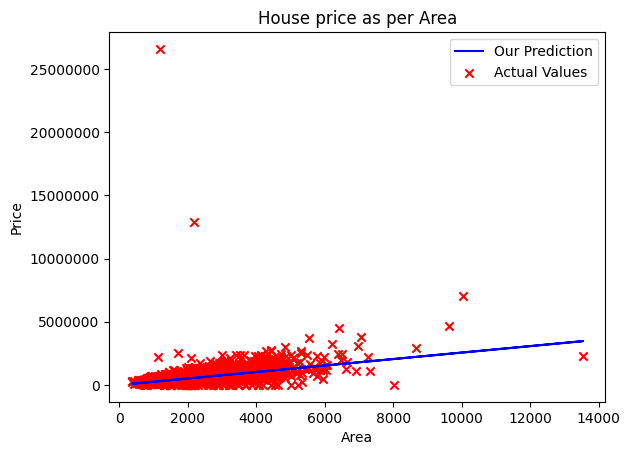

In [15]:
tmp_f_wb = compute_output(x_train, w_final, b_final)
plt.plot(x_train, tmp_f_wb, color="b", label="Our Prediction")
plt.scatter(x_train, y_train, marker="x", color="r", label="Actual Values")
plt.title(f"House price as per Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

In [16]:
area = int(input("What area of house are u looking to buy : "))

pred_cost = w_final * area + b_final

print(f"Predicted cost : Rs.{pred_cost}")

Predicted cost : Rs.2559408563.1531415
